In [20]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [21]:
df = pd.read_csv('Cleaned_SupplyChain_Data.csv')

In [22]:
#feature selection
features = [
    'Type', 'scheduled_shipping_days', 'Customer Segment', 
    'Market', 'region', 'Category Name', 'Shipping Mode', 
    'Order Item Quantity', 'Product Price', 'Order Item Discount Rate',
    'order_month', 'order_day'
]
X = df[features].copy()
y = df['late_flag']

In [23]:
# Encode categorical text into numbers
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
#model training
model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [26]:
df['Late_Probability'] = model.predict_proba(X)[:, 1]

In [27]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [28]:
y_pred = model.predict(X_test)

In [29]:
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 69.87%

Detailed Report:
              precision    recall  f1-score   support

           0       0.60      0.89      0.71     15399
           1       0.87      0.56      0.68     20705

    accuracy                           0.70     36104
   macro avg       0.73      0.72      0.70     36104
weighted avg       0.75      0.70      0.70     36104



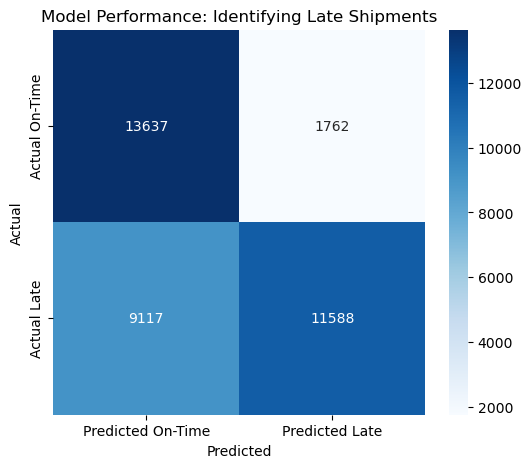

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted On-Time', 'Predicted Late'],
            yticklabels=['Actual On-Time', 'Actual Late'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Model Performance: Identifying Late Shipments')
plt.show()

In [31]:
#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['Product Price', 'Order Item Quantity', 'scheduled_shipping_days', 'Order Item Discount Rate']
X[num_cols] = scaler.fit_transform(X[num_cols])

In [32]:
#cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(f"Average Accuracy: {scores.mean():.2%}")
print(f"Accuracy Standard Deviation: {scores.std():.2%}")

Average Accuracy: 67.13%
Accuracy Standard Deviation: 2.21%


In [33]:
# hyperparameter Tuning
model = xgb.XGBClassifier(
    n_estimators=200,      
    learning_rate=0.05,    
    max_depth=7,           
    subsample=0.8,        
    colsample_bytree=0.8, 
    random_state=42
)

In [34]:
model.fit(X_train, y_train)
df['Late_Probability'] = model.predict_proba(X)[:, 1]
df['Predicted_Late'] = (df['Late_Probability'] > 0.5).astype(int)

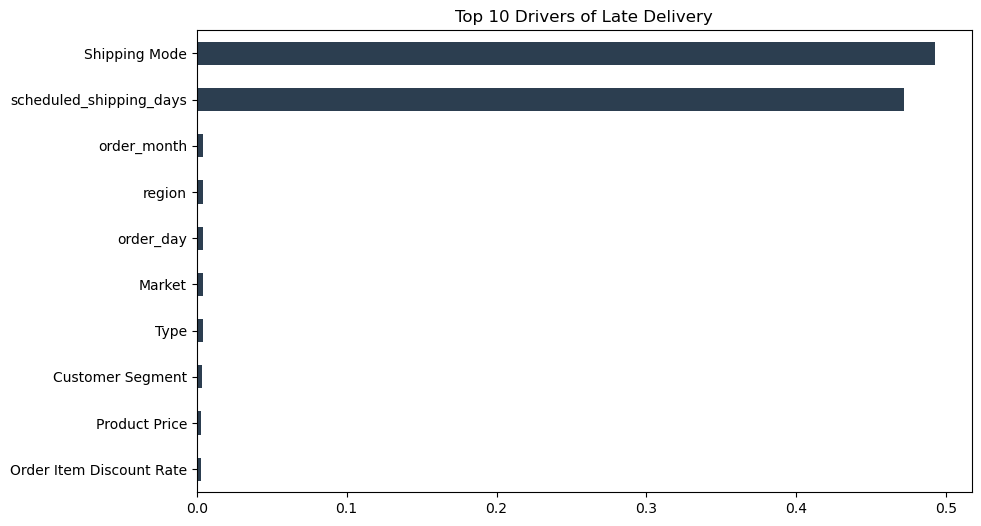

In [35]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='#2c3e50')
plt.title('Top 10 Drivers of Late Delivery')
plt.show()

In [36]:
df.to_csv('SupplyChain_Final_ML.csv')